🚀 Thiết bị: mps | Đang khởi động 50 Epochs...


/opt/homebrew/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



🔥 Bắt đầu huấn luyện: CIFAR-10
Epoch 1/50 - Loss: 1.6441 - Acc: 43.93%
Epoch 2/50 - Loss: 1.0445 - Acc: 62.40%
Epoch 3/50 - Loss: 0.8577 - Acc: 69.52%
Epoch 4/50 - Loss: 0.7471 - Acc: 73.69%
Epoch 5/50 - Loss: 0.6652 - Acc: 76.48%
Epoch 6/50 - Loss: 0.6076 - Acc: 78.32%
Epoch 7/50 - Loss: 0.5511 - Acc: 80.25%
Epoch 8/50 - Loss: 0.5075 - Acc: 81.94%
Epoch 9/50 - Loss: 0.4644 - Acc: 83.43%
Epoch 10/50 - Loss: 0.4277 - Acc: 84.70%
Epoch 11/50 - Loss: 0.3895 - Acc: 86.18%
Epoch 12/50 - Loss: 0.3643 - Acc: 87.03%
Epoch 13/50 - Loss: 0.3275 - Acc: 88.39%
Epoch 14/50 - Loss: 0.3032 - Acc: 89.07%
Epoch 15/50 - Loss: 0.2763 - Acc: 90.03%
Epoch 16/50 - Loss: 0.2482 - Acc: 91.04%
Epoch 17/50 - Loss: 0.2355 - Acc: 91.46%
Epoch 18/50 - Loss: 0.2209 - Acc: 92.10%
Epoch 19/50 - Loss: 0.1975 - Acc: 92.93%
Epoch 20/50 - Loss: 0.1839 - Acc: 93.37%
Epoch 21/50 - Loss: 0.1668 - Acc: 94.02%
Epoch 22/50 - Loss: 0.1566 - Acc: 94.31%
Epoch 23/50 - Loss: 0.1492 - Acc: 94.62%
Epoch 24/50 - Loss: 0.1406 - Acc: 

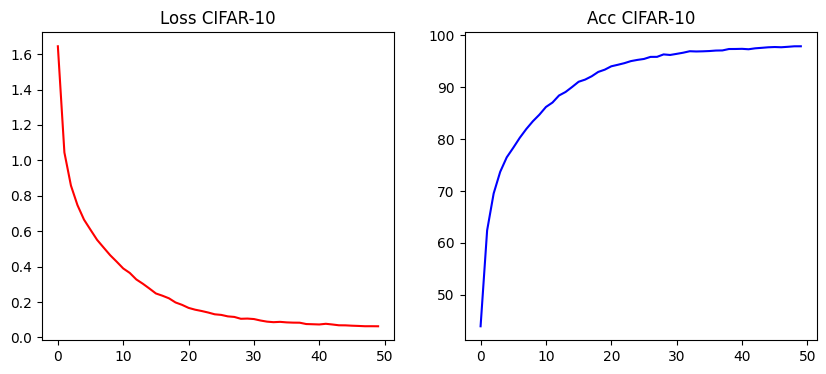


🔥 Bắt đầu huấn luyện: Cats vs Dogs
Epoch 1/50 - Loss: 0.7228 - Acc: 66.49%
Epoch 2/50 - Loss: 0.4437 - Acc: 79.22%
Epoch 3/50 - Loss: 0.3655 - Acc: 83.68%
Epoch 4/50 - Loss: 0.3107 - Acc: 86.63%
Epoch 5/50 - Loss: 0.2688 - Acc: 88.78%
Epoch 6/50 - Loss: 0.2363 - Acc: 90.14%
Epoch 7/50 - Loss: 0.2042 - Acc: 91.58%
Epoch 8/50 - Loss: 0.1839 - Acc: 92.58%
Epoch 9/50 - Loss: 0.1696 - Acc: 93.13%
Epoch 10/50 - Loss: 0.1454 - Acc: 94.14%
Epoch 11/50 - Loss: 0.1288 - Acc: 94.88%
Epoch 12/50 - Loss: 0.1140 - Acc: 95.49%
Epoch 13/50 - Loss: 0.1055 - Acc: 95.83%
Epoch 14/50 - Loss: 0.0908 - Acc: 96.38%
Epoch 15/50 - Loss: 0.0851 - Acc: 96.68%
Epoch 16/50 - Loss: 0.0766 - Acc: 97.02%
Epoch 17/50 - Loss: 0.0701 - Acc: 97.29%
Epoch 18/50 - Loss: 0.0661 - Acc: 97.36%
Epoch 19/50 - Loss: 0.0567 - Acc: 97.82%
Epoch 20/50 - Loss: 0.0545 - Acc: 97.86%
Epoch 21/50 - Loss: 0.0485 - Acc: 98.23%
Epoch 22/50 - Loss: 0.0467 - Acc: 98.22%
Epoch 23/50 - Loss: 0.0371 - Acc: 98.60%
Epoch 24/50 - Loss: 0.0457 - A

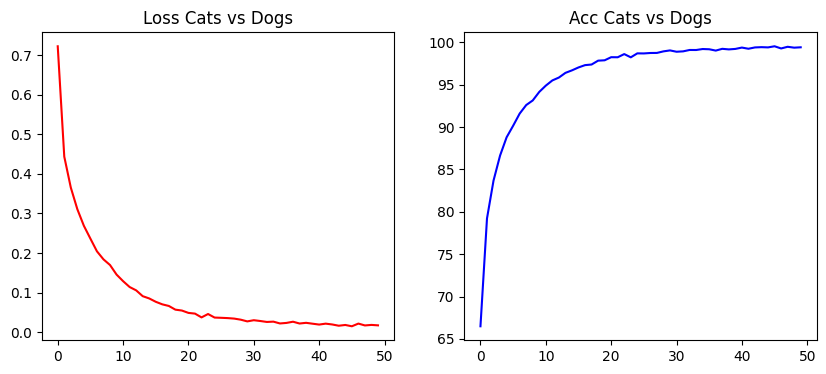


🔥 Bắt đầu huấn luyện: Plants


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder, CIFAR10
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import os
from PIL import Image

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"🚀 Thiết bị: {device} | Đang khởi động 50 Epochs...")

class UniversalCNN(nn.Module):
    def __init__(self, num_classes):
        super(UniversalCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def train_and_plot(model, loader, name, filename, epochs=50):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)
    
    loss_history, acc_history = [], []
    best_acc = 0.0
    
    print(f"\n🔥 Bắt đầu huấn luyện: {name}")
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(loader)
        epoch_acc = 100 * correct / total
        current_lr = optimizer.param_groups[0]['lr']
        
        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)
        scheduler.step(epoch_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.2f}%")
        
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            classes = getattr(loader.dataset, 'classes', ['Cat', 'Dog'] if 'catdog' in filename else None)
            torch.save({'state': model.state_dict(), 'classes': classes}, filename)

    print(f"✅ Đã lưu model tốt nhất: {filename}")
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.plot(loss_history, color='red'); plt.title(f'Loss {name}')
    plt.subplot(1, 2, 2); plt.plot(acc_history, color='blue'); plt.title(f'Acc {name}')
    plt.show()

trans = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# 1. CIFAR-10
ds_cifar = CIFAR10(root='./data', train=True, download=True, transform=trans)
train_and_plot(UniversalCNN(10), DataLoader(ds_cifar, 128, True), "CIFAR-10", "model_cifar.pth")

# 2. Chó & Mèo
class CatDogDataset(Dataset):
    def __init__(self, root, transform):
        self.files = [os.path.join(root, f) for f in os.listdir(root) if f.endswith('.jpg')]
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        p = self.files[idx]
        l = 0 if 'cat' in os.path.basename(p).lower() else 1
        return self.transform(Image.open(p).convert('RGB')), l

ds_cd = CatDogDataset('./dogs-vs-cats/train', trans)
train_and_plot(UniversalCNN(2), DataLoader(ds_cd, 64, True), "Cats vs Dogs", "model_catdog.pth")

# 3. Bệnh cây trồng
ds_p = ImageFolder('./plantvillage dataset/color', trans)
train_and_plot(UniversalCNN(len(ds_p.classes)), DataLoader(ds_p, 64, True), "Plants", "model_plant.pth")

🚀 Đang tập trung huấn luyện bộ PLANT trên: mps
🌿 Tìm thấy 38 loại bệnh cây trồng. Bắt đầu!
Epoch 1/50 - Loss: 0.7597 - Acc: 78.12% 
Epoch 2/50 - Loss: 0.2602 - Acc: 91.49% 
Epoch 3/50 - Loss: 0.1863 - Acc: 93.90% 
Epoch 4/50 - Loss: 0.1415 - Acc: 95.41% 
Epoch 5/50 - Loss: 0.1197 - Acc: 96.19% 
Epoch 6/50 - Loss: 0.1024 - Acc: 96.66% 
Epoch 7/50 - Loss: 0.0847 - Acc: 97.14% 
Epoch 8/50 - Loss: 0.0772 - Acc: 97.44% 
Epoch 9/50 - Loss: 0.0697 - Acc: 97.70% 
Epoch 10/50 - Loss: 0.0587 - Acc: 98.06% 
Epoch 11/50 - Loss: 0.0551 - Acc: 98.22% 
Epoch 12/50 - Loss: 0.0515 - Acc: 98.24% 
Epoch 13/50 - Loss: 0.0443 - Acc: 98.58% 
Epoch 14/50 - Loss: 0.0429 - Acc: 98.59% 
Epoch 15/50 - Loss: 0.0367 - Acc: 98.78% 
Epoch 16/50 - Loss: 0.0383 - Acc: 98.80% 
Epoch 17/50 - Loss: 0.0349 - Acc: 98.85% 
Epoch 18/50 - Loss: 0.0300 - Acc: 99.05% 
Epoch 19/50 - Loss: 0.0308 - Acc: 99.00% 
Epoch 20/50 - Loss: 0.0307 - Acc: 99.00% 
Epoch 21/50 - Loss: 0.0268 - Acc: 99.11% 
Epoch 22/50 - Loss: 0.0220 - Acc: 99

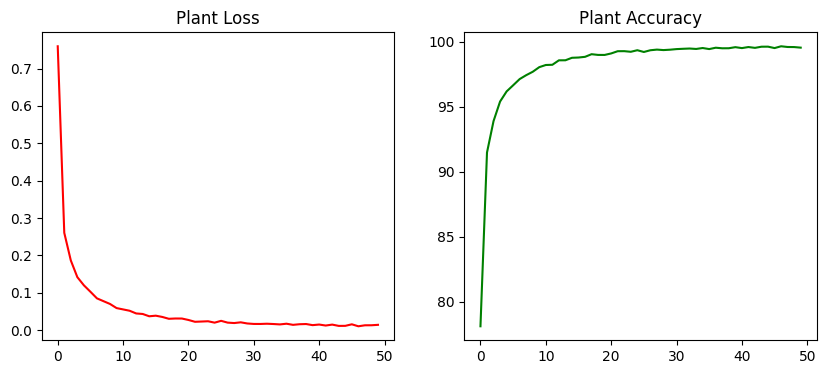

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"🚀 Đang tập trung huấn luyện bộ PLANT trên: {device}")

class UniversalCNN(nn.Module):
    def __init__(self, num_classes):
        super(UniversalCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

data_path = './plantvillage dataset/color' 

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

dataset = ImageFolder(root=data_path, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4)
num_classes = len(dataset.classes)

print(f"🌿 Tìm thấy {num_classes} loại bệnh cây trồng. Bắt đầu!")

model = UniversalCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

epochs = 50
best_acc = 0.0
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()
        
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    loss_history.append(epoch_loss)
    acc_history.append(epoch_acc)
    scheduler.step(epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.2f}% ")

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save({'state': model.state_dict(), 'classes': dataset.classes}, 'model_plant.pth')

print(f"✅ Hoàn tất! Model tốt nhất đã lưu tại: model_plant.pth")

# Vẽ biểu đồ
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(loss_history, color='red'); plt.title('Plant Loss')
plt.subplot(1,2,2); plt.plot(acc_history, color='green'); plt.title('Plant Accuracy')
plt.show()